# Question 3: Solar Irradiance Forecasting with Feature Engineering and CatBoost

## Overview

You are given hourly weather and solar irradiance data for Bangkok from NASA POWER. Forecast the measured irradiance value for the next hour.

This problem requires building features that capture time periodicity, sun position, and weather conditions, along with summarizing the past 48 hours (mean, standard deviation, and lag) before feeding them into a CatBoost model.

## Description

The data is split by time to simulate a genuine real-world forecast. The files provided are raw data from NASA POWER that has not been turned into features yet; you must build your own features (cyclic time, sun position, wind components, etc.) before feeding them into a model.

- `train.csv`: target time years 2019-2022, 35,063 rows, with raw columns and `target`
- `validation.csv`: target time year 2023, 8,760 rows, with raw columns and `target`
- `test.csv`: target time year 2024, 8,784 rows, with the same raw columns but no `target`

The raw columns from NASA POWER are `CLRSKY_SFC_SW_DWN`, `T2M`, `T2MDEW`, `RH2M`, `PS`, `WS10M`, `WD10M`, `PRECTOTCORR`, and `CLOUD_AMT`.

Every file has the same timestamp, target time, and feature columns. The test set has no target values, but you can concatenate the tail of validation with the start of test to build the 48-hour lookback without using future data.

## Public Data

File structure under `data/public`:

```text
train.csv
validation.csv
test.csv
```

`train.csv` and `validation.csv` have a `target` column, while `test.csv` does not. All three files are ordered by time and must not be shuffled before building lookback features.

## Evaluation

Evaluated with MAE, RMSE, and R-squared, reporting both across all time periods and specifically for periods where the true irradiance value is greater than 20.

```text
MAE = mean(abs(y_true - y_pred))
RMSE = sqrt(mean((y_true - y_pred)^2))
```

## Submission File

Submit `submission_solar.csv` with 8,784 rows.

```csv
id,predicted_ghi
0,0.0
1,0.0
2,5.7
```

- `id`: the row order of `test.csv`
- `predicted_ghi`: the measured irradiance value for the next hour predicted by the model; must not be negative.


In [1]:
import math, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor, Pool

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("catboost ready")


catboost ready


In [2]:
data_dir = Path("data")
public_dir = data_dir / "public"

train_table = pd.read_csv(public_dir / "train.csv", parse_dates=["timestamp", "target_time"])
validation_table = pd.read_csv(public_dir / "validation.csv", parse_dates=["timestamp", "target_time"])
test_table = pd.read_csv(public_dir / "test.csv", parse_dates=["timestamp", "target_time"])

print("train:", train_table.shape, train_table.columns.tolist())
print("validation:", validation_table.shape, validation_table.columns.tolist())
print("test:", test_table.shape, test_table.columns.tolist())
print("target present in test:", "target" in test_table.columns)
train_table.head()


train: (35063, 13) ['id', 'timestamp', 'target_time', 'CLRSKY_SFC_SW_DWN', 'T2M', 'T2MDEW', 'RH2M', 'PS', 'WS10M', 'WD10M', 'PRECTOTCORR', 'CLOUD_AMT', 'target']
validation: (8760, 13) ['id', 'timestamp', 'target_time', 'CLRSKY_SFC_SW_DWN', 'T2M', 'T2MDEW', 'RH2M', 'PS', 'WS10M', 'WD10M', 'PRECTOTCORR', 'CLOUD_AMT', 'target']
test: (8784, 12) ['id', 'timestamp', 'target_time', 'CLRSKY_SFC_SW_DWN', 'T2M', 'T2MDEW', 'RH2M', 'PS', 'WS10M', 'WD10M', 'PRECTOTCORR', 'CLOUD_AMT']
target present in test: False


,id,timestamp,target_time,CLRSKY_SFC_SW_DWN,T2M,T2MDEW,RH2M,PS,WS10M,WD10M,PRECTOTCORR,CLOUD_AMT,target
0,0,2019-01-01 00:00:00,2019-01-01 01:00:00,0.0,20.69,14.38,67.25,101.63,4.50,38.5,0.0,20.87,0.0
1,1,2019-01-01 01:00:00,2019-01-01 02:00:00,0.0,19.76,14.21,70.30,101.59,3.85,37.4,0.0,44.00,0.0
2,2,2019-01-01 02:00:00,2019-01-01 03:00:00,0.0,19.19,14.02,71.94,101.56,3.68,38.1,0.0,19.92,0.0
3,3,2019-01-01 03:00:00,2019-01-01 04:00:00,0.0,18.86,13.72,72.02,101.55,3.70,41.7,0.0,58.02,0.0
4,4,2019-01-01 04:00:00,2019-01-01 05:00:00,0.0,18.32,13.79,74.83,101.59,3.08,38.4,0.0,73.53,0.0


,count,mean,min,25%,50%,75%,max,std
id,35063.0,17531.0,0.0,8765.5,17531.0,26296.5,35062.0,10121.960581
timestamp,35063,2020-12-31 11:00:00,2019-01-01 00:00:00,2020-01-01 05:30:00,2020-12-31 11:00:00,2021-12-31 16:30:00,2022-12-31 22:00:00,NaN
target_time,35063,2020-12-31 12:00:00,2019-01-01 01:00:00,2020-01-01 06:30:00,2020-12-31 12:00:00,2021-12-31 17:30:00,2022-12-31 23:00:00,NaN
CLRSKY_SFC_SW_DWN,35063.0,265.304906,0.0,0.0,10.75,589.51,1012.92,340.799156
T2M,35063.0,27.948824,13.09,25.43,27.38,30.38,41.96,4.031678
T2MDEW,35063.0,22.566794,4.87,21.06,23.69,24.81,27.28,3.132425
RH2M,35063.0,75.540939,13.58,64.32,80.54,91.4,100.0,18.61495
PS,35063.0,100.844285,99.76,100.63,100.82,101.05,101.97,0.300331
WS10M,35063.0,2.791399,0.04,1.94,2.61,3.51,10.1,1.222133
WD10M,35063.0,167.676112,0.0,80.7,188.1,228.3,359.8,83.446322


missing values (train):


,missing
id,0
timestamp,0
target_time,0
CLRSKY_SFC_SW_DWN,0
T2M,0
T2MDEW,0
RH2M,0
PS,0
WS10M,0
WD10M,0


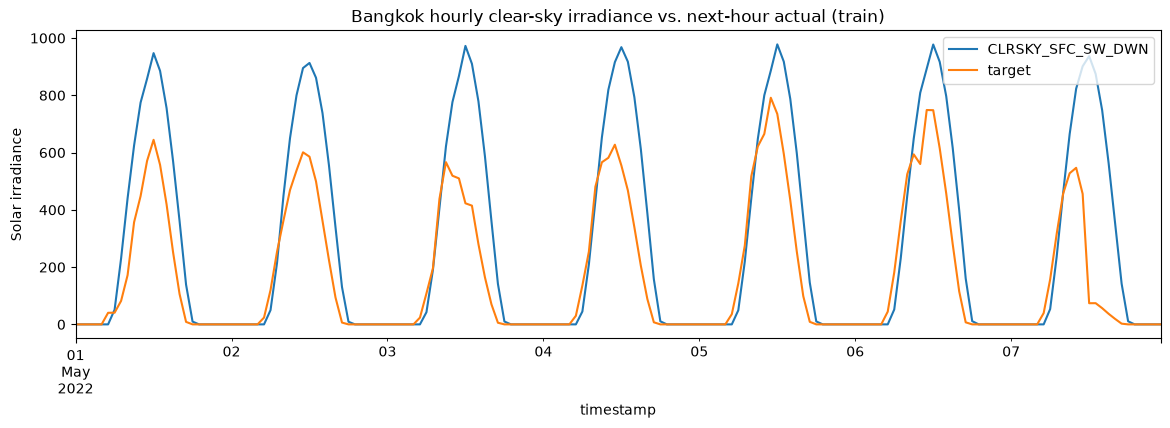

In [3]:
display(train_table.describe().T.round(3))
print("missing values (train):")
display(train_table.isna().sum().to_frame("missing"))

sample = train_table.set_index("timestamp").loc["2022-05-01":"2022-05-07", ["CLRSKY_SFC_SW_DWN", "target"]]
fig, ax1 = plt.subplots(figsize=(14, 4))
sample.plot(ax=ax1)
ax1.set_ylabel("Solar irradiance")
plt.title("Bangkok hourly clear-sky irradiance vs. next-hour actual (train)")
plt.show()


In [4]:
combined = pd.concat([
    train_table.assign(split="train"),
    validation_table.assign(split="validation"),
    test_table.assign(split="test"),
], ignore_index=True, sort=False).sort_values("timestamp").reset_index(drop=True)

RAW_COLUMNS = ["CLRSKY_SFC_SW_DWN", "T2M", "T2MDEW", "RH2M", "PS", "WS10M", "WD10M", "PRECTOTCORR", "CLOUD_AMT"]

data = combined.set_index("timestamp")
for column in RAW_COLUMNS:
    data[column] = data[column].mask(data[column] <= -900)
data["PRECTOTCORR"] = data["PRECTOTCORR"].clip(lower=0).fillna(0)
for column in RAW_COLUMNS:
    data[column] = data[column].ffill(limit=3)
    data[column] = data[column].fillna(data.loc[data.split == "train", column].median())

hour = data.index.hour.to_numpy()
day = data.index.dayofyear.to_numpy()
gamma = 2 * np.pi * (day - 1 + (hour - 12) / 24) / 365.25
declination = (0.006918 - 0.399912 * np.cos(gamma) + 0.070257 * np.sin(gamma) - 0.006758 * np.cos(2 * gamma) + 0.000907 * np.sin(2 * gamma) - 0.002697 * np.cos(3 * gamma) + 0.00148 * np.sin(3 * gamma))
equation = 229.18 * (0.000075 + 0.001868 * np.cos(gamma) - 0.032077 * np.sin(gamma) - 0.014615 * np.cos(2 * gamma) - 0.040849 * np.sin(2 * gamma))
latitude = np.deg2rad(13.7563)
solar_minutes = hour * 60 + equation + 4 * (100.5018 - 105.0)
hour_angle = np.deg2rad(solar_minutes / 4 - 180)
cos_zenith = np.sin(latitude) * np.sin(declination) + np.cos(latitude) * np.cos(declination) * np.cos(hour_angle)

data["hour_sin"] = np.sin(2 * np.pi * hour / 24)
data["hour_cos"] = np.cos(2 * np.pi * hour / 24)
data["day_sin"] = np.sin(2 * np.pi * day / 365.25)
data["day_cos"] = np.cos(2 * np.pi * day / 365.25)
data["declination"] = declination
data["cos_zenith"] = np.clip(cos_zenith, 0, None)
data["daylight"] = (cos_zenith > 0).astype(float)

next_hour = (hour + 1) % 24
next_day = day + (hour == 23)
next_gamma = 2 * np.pi * (next_day - 1 + (next_hour - 12) / 24) / 365.25
next_declination = (0.006918 - 0.399912 * np.cos(next_gamma) + 0.070257 * np.sin(next_gamma) - 0.006758 * np.cos(2 * next_gamma) + 0.000907 * np.sin(2 * next_gamma) - 0.002697 * np.cos(3 * next_gamma) + 0.00148 * np.sin(3 * next_gamma))
next_equation = 229.18 * (0.000075 + 0.001868 * np.cos(next_gamma) - 0.032077 * np.sin(next_gamma) - 0.014615 * np.cos(2 * next_gamma) - 0.040849 * np.sin(2 * next_gamma))
next_minutes = next_hour * 60 + next_equation + 4 * (100.5018 - 105.0)
next_angle = np.deg2rad(next_minutes / 4 - 180)
next_cos_zenith = np.sin(latitude) * np.sin(next_declination) + np.cos(latitude) * np.cos(next_declination) * np.cos(next_angle)

data["next_hour_sin"] = np.sin(2 * np.pi * next_hour / 24)
data["next_hour_cos"] = np.cos(2 * np.pi * next_hour / 24)
data["next_cos_zenith"] = np.clip(next_cos_zenith, 0, None)

data["temp_dew_spread"] = data.T2M - data.T2MDEW
wind_rad = np.deg2rad(data.WD10M)
data["wind_u"] = data.WS10M * np.sin(wind_rad)
data["wind_v"] = data.WS10M * np.cos(wind_rad)

data = data.reset_index()
print("engineered shape:", data.shape)
print("features created:", len(data.columns) - len(combined.columns))
data.head()


engineered shape: (52607, 27)
features created: 13


,timestamp,id,target_time,CLRSKY_SFC_SW_DWN,T2M,T2MDEW,RH2M,PS,WS10M,WD10M,...,day_cos,declination,cos_zenith,daylight,next_hour_sin,next_hour_cos,next_cos_zenith,temp_dew_spread,wind_u,wind_v
0,2019-01-01 00:00:00,0,2019-01-01 01:00:00,0.0,20.69,14.38,67.25,101.63,4.50,38.5,...,0.999852,-0.403090,0.0,0.0,0.258819,0.965926,0.0,6.31,2.801316,3.521737
1,2019-01-01 01:00:00,1,2019-01-01 02:00:00,0.0,19.76,14.21,70.30,101.59,3.85,37.4,...,0.999852,-0.403038,0.0,0.0,0.500000,0.866025,0.0,5.55,2.338397,3.058496
2,2019-01-01 02:00:00,2,2019-01-01 03:00:00,0.0,19.19,14.02,71.94,101.56,3.68,38.1,...,0.999852,-0.402986,0.0,0.0,0.707107,0.707107,0.0,5.17,2.270692,2.895921
3,2019-01-01 03:00:00,3,2019-01-01 04:00:00,0.0,18.86,13.72,72.02,101.55,3.70,41.7,...,0.999852,-0.402933,0.0,0.0,0.866025,0.500000,0.0,5.14,2.461352,2.762561
4,2019-01-01 04:00:00,4,2019-01-01 05:00:00,0.0,18.32,13.79,74.83,101.59,3.08,38.4,...,0.999852,-0.402880,0.0,0.0,0.965926,0.258819,0.0,4.53,1.913135,2.413776


In [5]:
feature_cols = [c for c in data.columns if c not in ["id", "timestamp", "target_time", "target", "split", "WD10M"]]

LOOKBACK = 48
POOL_COLUMNS = ["CLRSKY_SFC_SW_DWN", "T2M", "T2MDEW", "RH2M", "PS", "WS10M",
                "PRECTOTCORR", "CLOUD_AMT", "temp_dew_spread", "wind_u", "wind_v"]

pooled = pd.DataFrame(index=data.index)
for column in POOL_COLUMNS:
    roll = data[column].rolling(LOOKBACK, min_periods=1)
    pooled[f"{column}_mean48"] = roll.mean()
    pooled[f"{column}_std48"] = roll.std().fillna(0.0)
    pooled[f"{column}_min48"] = roll.min()
    pooled[f"{column}_max48"] = roll.max()
    pooled[f"{column}_lag1"] = data[column].shift(1).fillna(data[column])
    pooled[f"{column}_lag24"] = data[column].shift(24).fillna(data[column])

model_data = pd.concat([data[feature_cols], pooled], axis=1)
model_feature_cols = feature_cols + list(pooled.columns)
target = data.target.to_numpy(np.float32)

train_mask = (data.split == "train").to_numpy()
val_mask = (data.split == "validation").to_numpy()
test_mask = (data.split == "test").to_numpy()

X_train, y_train = model_data.loc[train_mask], target[train_mask]
X_val, y_val = model_data.loc[val_mask], target[val_mask]
X_test = model_data.loc[test_mask]

print("features:", len(model_feature_cols))
print("rows:", len(X_train), len(X_val), len(X_test))


features: 87
rows: 35063 8760 8784


In [6]:
train_pool = Pool(X_train, y_train)
val_pool = Pool(X_val, y_val)

model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    eval_metric="MAE",
    random_seed=SEED,
    early_stopping_rounds=100,
    verbose=200,
)
model.fit(train_pool, eval_set=val_pool)

print("best iteration:", model.get_best_iteration())
print("best validation MAE:", round(model.get_best_score()["validation"]["MAE"], 3))


0:	learn: 247.1245150	test: 249.5261947	best: 249.5261947 (0)	total: 60.1ms	remaining: 3m
200:	learn: 19.9660064	test: 18.9510040	best: 18.9510040 (200)	total: 2.47s	remaining: 34.4s
400:	learn: 17.1986955	test: 18.3336984	best: 18.3336984 (400)	total: 4.73s	remaining: 30.7s
600:	learn: 15.4257255	test: 18.1701169	best: 18.1621200 (577)	total: 7.01s	remaining: 28s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 18.16212
bestIteration = 577

Shrink model to first 578 iterations.
best iteration: 577
best validation MAE: 18.162


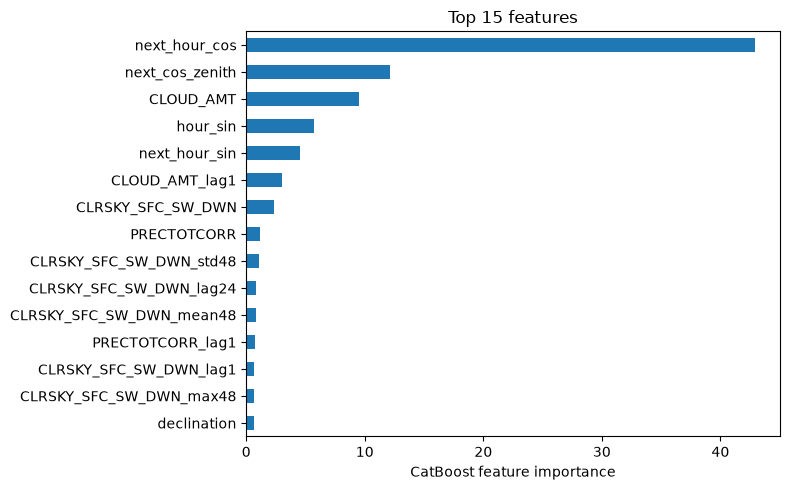

In [7]:
importances = pd.Series(model.get_feature_importance(train_pool), index=model_feature_cols)
top = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
top.iloc[::-1].plot.barh(ax=ax)
ax.set_xlabel("CatBoost feature importance")
ax.set_title("Top 15 features")
plt.tight_layout()
plt.show()


In [8]:
pred = np.clip(model.predict(X_test), 0, None)

val_pred = np.clip(model.predict(X_val), 0, None)
daylight = y_val > 20
print("validation MAE (all):", round(mean_absolute_error(y_val, val_pred), 3))
print("validation MAE (daylight only):", round(mean_absolute_error(y_val[daylight], val_pred[daylight]), 3))
print("validation RMSE:", round(mean_squared_error(y_val, val_pred) ** .5, 3))
print("validation R2:", round(r2_score(y_val, val_pred), 4))
print("test predictions:", pred.shape)


validation MAE (all): 17.73
validation MAE (daylight only): 34.92
validation RMSE: 39.338
validation R2: 0.9823
test predictions: (8784,)


In [9]:
submission = pd.DataFrame({"id": np.arange(len(pred)), "predicted_ghi": np.clip(pred, 0, None)})
submission.to_csv("submission_solar.csv", index=False)

print("public test columns:", test_table.columns.tolist())
print("target present:", "target" in test_table.columns)
print("submission:", submission.shape)
submission.head(10)

public test columns: ['id', 'timestamp', 'target_time', 'CLRSKY_SFC_SW_DWN', 'T2M', 'T2MDEW', 'RH2M', 'PS', 'WS10M', 'WD10M', 'PRECTOTCORR', 'CLOUD_AMT']
target present: False
submission: (8784, 2)


,id,predicted_ghi
0,0,0.000000
1,1,0.000000
2,2,0.000000
3,3,0.703287
4,4,0.005488
5,5,0.536224
6,6,8.885639
7,7,106.130214
8,8,320.457392
9,9,536.963072
